In [1]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,roc_curve)

In [2]:
#LOAD DATA
df = pd.read_csv("diabetic_data.csv")
print("Dataset:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)

Dataset:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No            

In [3]:
# REMOVE DUPLICATES
print("\nDuplicates : " , df.duplicated().sum())


Duplicates :  0


In [4]:
#CONVERT TARGET INTO BINARY
# <30  = Readmitted within 30 days = 1
# >30  = Readmitted after 30 days  = 0
# No   = Not readmitted             = 0
df["readmitted"] = (df["readmitted"] == "<30").astype(int)
print("\nTarget Distribution:")
print(df["readmitted"].value_counts())


Target Distribution:
readmitted
0    90409
1    11357
Name: count, dtype: int64


In [5]:
#SEPARATE FEATURES AND TARGET
X = df.drop(columns=["readmitted","encounter_id","patient_nbr"])
y = df["readmitted"]

In [6]:
#HANDLE MISSING VALUES
X = X.replace("?", pd.NA)
# Numerical columns
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns
# Fill numerical missing values with median
X[numerical_columns] = X[numerical_columns].fillna(X[numerical_columns].median())
# Categorical columns
categorical_columns = X.select_dtypes(include=["object"]).columns
# Fill categorical missing values with mode
for column in categorical_columns:
    X[column] = X[column].fillna(X[column].mode()[0])

In [7]:
#ENCODE CATEGORICAL FEATURES
X = pd.get_dummies(X,drop_first=True,dtype=int)
print("\nData after encoding:")
print(X.shape)


Data after encoding:
(101766, 2425)


In [8]:
#TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("\nTraining Data Shape:")
print(X_train.shape)
print("\nTesting Data Shape:")
print(X_test.shape)


Training Data Shape:
(81412, 2425)

Testing Data Shape:
(20354, 2425)


In [9]:
#FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
#TRAIN LOGISTIC REGRESSION
model = LogisticRegression(penalty="l2",max_iter=1000,random_state=4)
print("\nTraining Logistic Regression...")
model.fit(X_train_scaled,y_train)
print("Training Completed.")


Training Logistic Regression...
Training Completed.


In [11]:
#GET PREDICTIONS
# Probability of readmission
y_probability = model.predict_proba(X_test_scaled)[:, 1]
# Prediction using threshold 0.5
y_pred = (y_probability >= 0.5).astype(int)

In [12]:
#EVALUATION
print("\nClassification Report:")
print(classification_report(y_test,y_pred,zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.42      0.03      0.05      2271

    accuracy                           0.89     20354
   macro avg       0.66      0.51      0.49     20354
weighted avg       0.84      0.89      0.84     20354


Confusion Matrix:
[[18005    78]
 [ 2214    57]]


In [13]:
#ROC-AUC
roc_auc = roc_auc_score(y_test,y_probability)
print("\nROC-AUC Score:")
print(roc_auc)


ROC-AUC Score:
0.6361690295784448


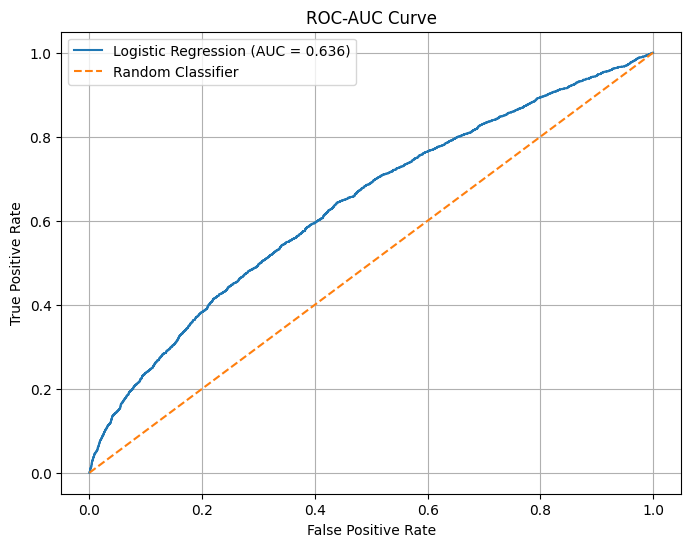

In [14]:
#ROC-AUC CURVE
fpr, tpr, thresholds = roc_curve(y_test,y_probability)
plt.figure(figsize=(8, 6))
plt.plot(fpr,tpr,label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1],[0, 1],linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.grid()
plt.savefig("roc_curve.png",dpi=300,bbox_inches="tight")
plt.show()

In [15]:
prediction_results = pd.DataFrame({"Actual": y_test.values,"Predicted": y_pred,"Readmission_Probability": y_probability})
prediction_results.to_csv("case_study1_predictions.csv",index=False)
print("\nPrediction file saved successfully:")
print("case_study1_predictions.csv")


Prediction file saved successfully:
case_study1_predictions.csv
